In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector


db = mysql.connector.connect(host = "localhost",
                            username = "root",
                            password = "password",
                            database = "grocery")

cur = db.cursor()


# Count the number of items sold in 2021.

In [35]:
query = """ select count(*) from annex2 where RIGHT(Date, 4) = 2021 """

cur.execute(query)

data = cur.fetchall()

"total items sold in 2021 are ", data[0][0]

('total items sold in 2021 are ', 298769)

# Find the total sales per item.

In [36]:
query = """ SELECT Item_Code_Text, SUM(`Quantity_Sold_(kilo)`*`Unit_Selling_Price_(RMB/kg)`) AS total_sales
FROM annex2
GROUP BY Item_Code_Text; """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Item", "Sales"])
df

,Item,Sales
0,'102900005117056,95568.633659
1,'102900005115960,38758.685440
2,'102900005115823,56891.463123
3,'102900005115908,32783.369605
4,'102900005115779,129756.961355
...,...,...
241,'102900011036242,249.300002
242,'102900011035849,116.564000
243,'102900011021675,61.610398
244,'106972776821582,867.000024


# Find the Total Sales per Catagory.

In [37]:
query = """ SELECT annex1.Category_Name catagory, SUM(`Quantity_Sold_(kilo)`*`Unit_Selling_Price_(RMB/kg)`) AS total_sales
FROM annex1 join annex2 on annex1.Item_Code_Text = annex2.Item_Code_Text
GROUP BY catagory; """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Catagory", "Sales"])
df

,Catagory,Sales
0,Capsicum,7.541330e+05
1,Flower/Leaf Vegetables,1.079070e+06
2,Aquatic Tuberous Vegetables,3.500899e+05
3,Edible Mushroom,6.195978e+05
4,Cabbage,3.757517e+05
5,Solanum,1.911243e+05


# Calculate the percentage of transactions that were sales as compared to returns.

In [38]:
query = """ select ((sum(case when Sale_or_Return = 'sale' then 1
else 0 end))/count(*))*100 from annex2
"""

cur.execute(query)

data = cur.fetchall()

"the percentage of transactions that were sales is", data[0][0]

('the percentage of transactions that were sales is', Decimal('99.9475'))

# Count the number of transactions that were discounted.

In [39]:
query = """ select ((sum(case when `Discount_(Yes/No)` = 'Yes' then 1
else 0 end))/count(*))*100 from annex2
"""

cur.execute(query)

data = cur.fetchall()

"the percentage of transactions that were discounted is", data[0][0]

('the percentage of transactions that were discounted is', Decimal('5.3917'))

# Calculate the number of orders per month in 2022.

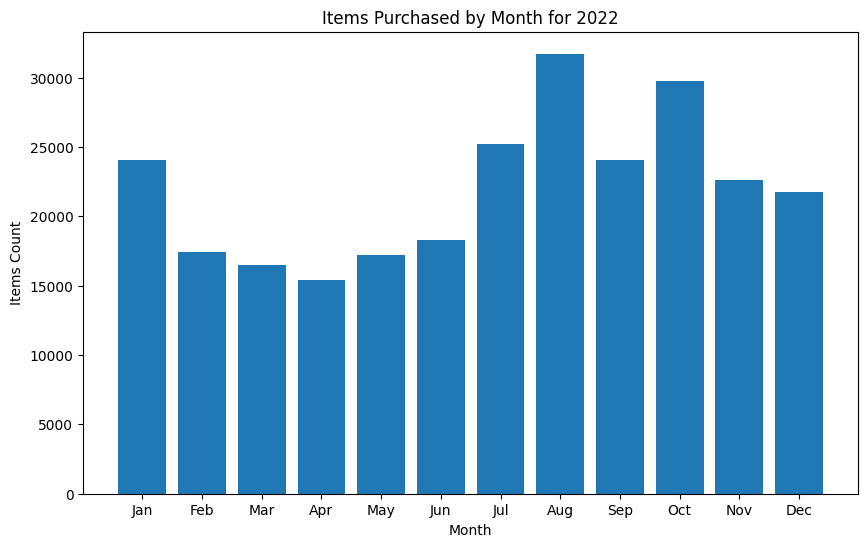

In [40]:
import matplotlib.pyplot as plt

query = """ select LEFT(Date, 2) month, count(Item_Code_Text) item_count
from annex2 where RIGHT(Date, 4) = 2022
GROUP BY month
"""

cur.execute(query)

data = cur.fetchall()

# Convert month numbers to month names
month_names = {
    "1/": "Jan", "2/": "Feb", "3/": "Mar",
    "4/": "Apr", "5/": "May", "6/": "Jun",
    "7/": "Jul", "8/": "Aug", "9/": "Sep",
    "10": "Oct", "11": "Nov", "12": "Dec"
}

month = [month_names[row[0]] for row in data]
item_counts = [row[1] for row in data]

# Create bar chart
plt.figure(figsize=(10, 6))
plt.bar(month, item_counts)

# Labels and title
plt.xlabel("Month")
plt.ylabel("Items Count")
plt.title("Items Purchased by Month for 2022")

plt.show()

# Calculate the average loss rate for each catagory.

In [41]:
query = """
SELECT annex1.Category_Name AS catagory,
       AVG(`Loss_Rate_(%)`) AS avg_loss_rate
FROM annex1
JOIN annex4 ON annex1.Item_Code_Text = annex4.Item_Code_Text
GROUP BY annex1.Category_Name
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Catagory", "Average Loss Rate"])
df

,Catagory,Average Loss Rate
0,Flower/Leaf Vegetables,10.280300
1,Edible Mushroom,8.130972
2,Aquatic Tuberous Vegetables,11.974737
3,Capsicum,8.515333
4,Solanum,7.122000
5,Cabbage,14.142000


# Calculate the percentage of total revenue contributed by each product category.

In [42]:
query = """
SELECT
annex1.Category_Name AS catagory,
SUM(`Quantity_Sold_(kilo)` * `Unit_Selling_Price_(RMB/kg)`) AS total_sales,
100.0 * SUM(`Quantity_Sold_(kilo)` * `Unit_Selling_Price_(RMB/kg)`)
/ SUM(SUM(`Quantity_Sold_(kilo)` * `Unit_Selling_Price_(RMB/kg)`)) OVER () AS pct_of_total
FROM annex1
JOIN annex2 ON annex1.Item_Code_Text = annex2.Item_Code_Text
GROUP BY catagory;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Catagory", "Sales", "Percentage of Total Sales"])
df

,Catagory,Sales,Percentage of Total Sales
0,Capsicum,7.541330e+05,22.379385
1,Flower/Leaf Vegetables,1.079070e+06,32.022094
2,Aquatic Tuberous Vegetables,3.500899e+05,10.389144
3,Edible Mushroom,6.195978e+05,18.386965
4,Cabbage,3.757517e+05,11.150675
5,Solanum,1.911243e+05,5.671736


# Identify the correlation between product price and the number of times a product has been purchased.

In [43]:
query = """select annex1.Category_Name AS catagory, 
COUNT(annex2.Item_Code_Text) item_count,
AVG(`Quantity_Sold_(kilo)`*`Unit_Selling_Price_(RMB/kg)`) AS avg_sales
from annex1 join annex2
ON annex1.Item_Code_Text = annex2.Item_Code_Text
GROUP BY catagory"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns = ["Category", "order_count","price"])
print(df)

arr1 = df["order_count"]
arr2 = df["price"]

a = np.corrcoef([arr1,arr2])
print("the correlation is", a[0][-1])

                      Category  order_count     price
0                     Capsicum       207996  3.625709
1       Flower/Leaf Vegetables       331968  3.250524
2  Aquatic Tuberous Vegetables        58647  5.969443
3              Edible Mushroom       148424  4.174512
4                      Cabbage        86570  4.340438
5                      Solanum        44898  4.256855
the correlation is -0.746471307175303


#  Calculate the average number of items sold during each month of the year.

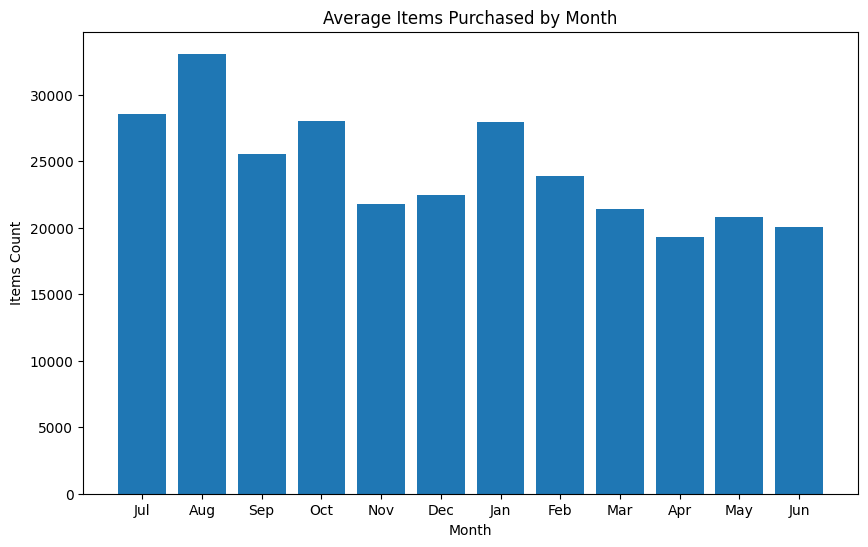

In [44]:
query = """ WITH monthly AS (
  SELECT
    LEFT(Date, 2) AS month,
    RIGHT(Date, 4) AS year,
    COUNT(Item_Code_Text) AS item_count
  FROM annex2
  GROUP BY LEFT(Date, 2), RIGHT(Date, 4)
)
SELECT
  month,
  AVG(item_count) AS avg_items_sold
FROM monthly
GROUP BY month
"""

cur.execute(query)

data = cur.fetchall()

# Convert month numbers to month names
month_names = {
    "1/": "Jan", "2/": "Feb", "3/": "Mar",
    "4/": "Apr", "5/": "May", "6/": "Jun",
    "7/": "Jul", "8/": "Aug", "9/": "Sep",
    "10": "Oct", "11": "Nov", "12": "Dec"
}

month = [month_names[row[0]] for row in data]
item_counts = [row[1] for row in data]

# Create bar chart
plt.figure(figsize=(10, 6))
plt.bar(month, item_counts)

# Labels and title
plt.xlabel("Month")
plt.ylabel("Items Count")
plt.title("Average Items Purchased by Month")

plt.show()

# Calculate the year-over-year growth rate of total sales.

In [53]:
query = """WITH yearly AS (
  SELECT
    RIGHT(Date, 4) AS year,
    SUM(`Quantity_Sold_(kilo)` * `Unit_Selling_Price_(RMB/kg)`) AS tot_sales
  FROM annex2
  GROUP BY RIGHT(Date, 4)
)
SELECT
  year,
  tot_sales,
  LAG(tot_sales) OVER (ORDER BY year) AS prev_year_sales,
  100.0 * (tot_sales - LAG(tot_sales) OVER (ORDER BY year))
        / NULLIF(LAG(tot_sales) OVER (ORDER BY year), 0) AS yoy_growth_pct
FROM yearly
ORDER BY year"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Year", "Total Sales", "Prev Year Sales", "YOY Growth Rate"])
df

,Year,Total Sales,Prev Year Sales,YOY Growth Rate
0,2020,6.695293e+05,NaN,NaN
1,2021,1.100363e+06,6.695293e+05,64.348700
2,2022,1.036772e+06,1.100363e+06,-5.779026
3,2023,5.631021e+05,1.036772e+06,-45.687004
